# 第 9 章 · BPE

「鲁迅写了狂人日记」：逐次合并最高频 byte pair。

配套交互演示：[章节网页](../ch9.html)

## 本节目标

- 统计 pair 频次
- 逐步 merge
- GIF 看 token 序列变化

## 1. 初始 token

语料先切成字符级 token；统计相邻 pair 出现次数。

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch09"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from bpe import *

In [2]:
display(first_merge_table())

,项目,内容
0,初始 token,鲁 / 迅 / 写 / 了 / 狂 / 人 / 日 / 记
1,TOP1 pair,鲁+迅: 1 次
2,TOP2 pair,迅+写: 1 次
3,TOP3 pair,写+了: 1 次
4,第 1 次合并,日+记 -> 日记


## 2. 逐步合并

**BPE**

```text
while vocab large:
  pair = argmax count(a,b)
  merge pair -> new token
```

In [3]:
bpe_frames = codelens_bpe_merges()

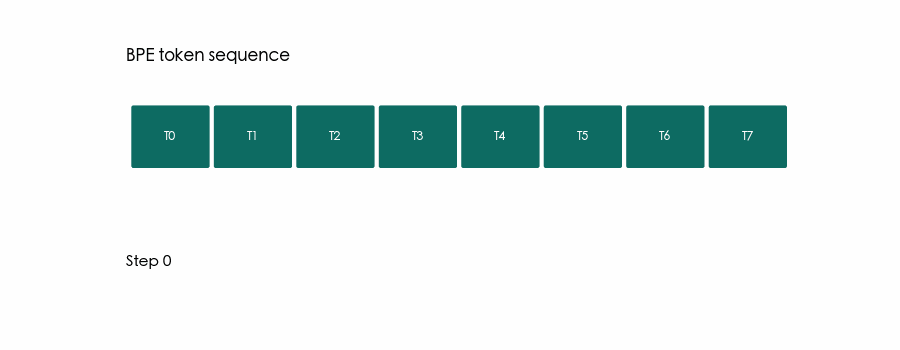

In [4]:
animate_bpe_merges()

In [5]:
display(steps_table())

,步骤,合并对,序列
0,0,—,鲁 / 迅 / 写 / 了 / 狂 / 人 / 日 / 记
1,1,日+记(12次),鲁 / 迅 / 写 / 了 / 狂 / 人 / 日记
2,2,狂+人(8次),鲁 / 迅 / 写 / 了 / 狂人 / 日记
3,3,鲁+迅(6次),鲁迅 / 写 / 了 / 狂人 / 日记


**思考** · 第一次合并哪一对？

<details><summary>查看答案</summary>

见 demo_first_merge 最高频 pair。

</details>

## 3. 与网页验证

每步 `与网页一致` 字段应为 True。

## 小结

BPE 由高频 pair 迭代合并子词。对照 [ch9.html](../ch9.html)。

## 练习

1. 为何先合并高频 pair？
2. 中文 BPE 与英文有何不同？